In [ ]:
pip install catboost

In [15]:
pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
    --------------------------------------- 0.0/1.5 MB 660.6 kB/s eta 0:00:03
   - -------------------------------------- 0.1/1.5 MB 653.6 kB/s eta 0:00:03
   --- ------------------------------------ 0.1/1.5 MB 804.6 kB/s eta 0:00:02
   ------ --------------------------------- 0.2/1.5 MB 1.1 MB/s eta 0:00:02
   -------- ------------------------------- 0.3/1.5 MB 1.3 MB/s eta 0:00:01
   ----------- ---------------------------- 0.4/1.5 MB 1.4 MB/s eta 0:00:01
   ----------- ---------------------------- 0.4/1.5 MB 1.4 MB/s eta 0:00:01
   ------------ --------------------------- 0.4/1.5 MB 1.2 MB/s eta 0:00:01
   ------------ --------------------------- 0.4/1.5 MB 1.2 MB/s eta 0:00:01
   --------------- ------------------------ 0.6/1.5 MB 1.2 MB/s eta 0:00:01
   ---------------- ----------------------- 0.6/1.5 MB 1.2 MB/s eta 0:00:01
   -----------------


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

df = pd.read_csv('../data/processed/telco_features.csv')  # Your new dataset


In [12]:
target_col = 'Churn'
feature_cols = [col for col in df.columns if col not in [target_col]]

# 3. Prepare X and y
X = df[feature_cols]
y = df[target_col]
# Your current one-hot encoded data is PERFECT for XGBoost
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# LogisticRegression


In [14]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(
    max_iter=2000,
    C=1.0
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75      6542
           1       0.70      0.90      0.78      5745

    accuracy                           0.77     12287
   macro avg       0.79      0.78      0.77     12287
weighted avg       0.79      0.77      0.77     12287

ROC AUC Score: 0.7857369360567414


c:\Users\Jmbo2\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 2000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=2000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# RandomForest

In [15]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75      6542
           1       0.70      0.90      0.78      5745

    accuracy                           0.77     12287
   macro avg       0.79      0.78      0.77     12287
weighted avg       0.79      0.77      0.77     12287

ROC AUC Score: 0.7873809559919317


# LGBM

In [16]:
# LightGBM example (my top pick)
import lightgbm as lgb

model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.88      0.66      0.75      6542
           1       0.70      0.90      0.78      5745

    accuracy                           0.77     12287
   macro avg       0.79      0.78      0.77     12287
weighted avg       0.79      0.77      0.77     12287

ROC AUC Score: 0.7869076668425404


# XGBOOST 

In [17]:
# model = XGBClassifier(
#     n_estimators=1000,
#     max_depth=8,
#     learning_rate=0.05,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     random_state=42,
#     eval_metric='auc'
# )

# model.fit(
#     X_train, y_train,
#     eval_set=[(X_test, y_test)],
#     verbose=0
# )


# y_proba = model.predict_proba(X_test)[:, 1]
# print(classification_report(y_test, y_pred))
# print(f"XGBoost AUC: {roc_auc_score(y_test, y_proba):.3f}")

from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [500, 1000, 1500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'gamma': [0, 0.1, 0.2],
    'min_child_weight': [1, 3, 5]
}

xgb = XGBClassifier(random_state=42, eval_metric='auc')
search = RandomizedSearchCV(
    xgb, param_dist, n_iter=50, cv=5, 
    scoring='roc_auc', verbose=1, n_jobs=-1
)

search.fit(X_train, y_train)


print(f"Best AUC: {search.best_score_:.3f}") 
print(f"Best params: {search.best_params_}")



Fitting 5 folds for each of 50 candidates, totalling 250 fits


c:\Users\Jmbo2\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py:516: FitFailedWarning: 
1 fits failed out of a total of 250.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\Jmbo2\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\model_selection\_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\Jmbo2\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py", line 726, in inner_f
    return func(**kwargs)
           ^^^^^^^^^^^^^^
  File "c:\Users\Jmbo2\AppData\Local\Programs\Python\Python311\Lib\site-package

Best AUC: 0.791
Best params: {'subsample': 0.8, 'n_estimators': 1000, 'min_child_weight': 1, 'max_depth': 4, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.7}


In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(search, X_train, y_train, cv=cv, scoring='roc_auc')

print(f"CV AUC: {scores.mean():.3f} (+/- {scores.std():.3f})")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Fitting 5 folds for each of 50 candidates, totalling 250 fits
CV AUC: 0.790 (+/- 0.005)


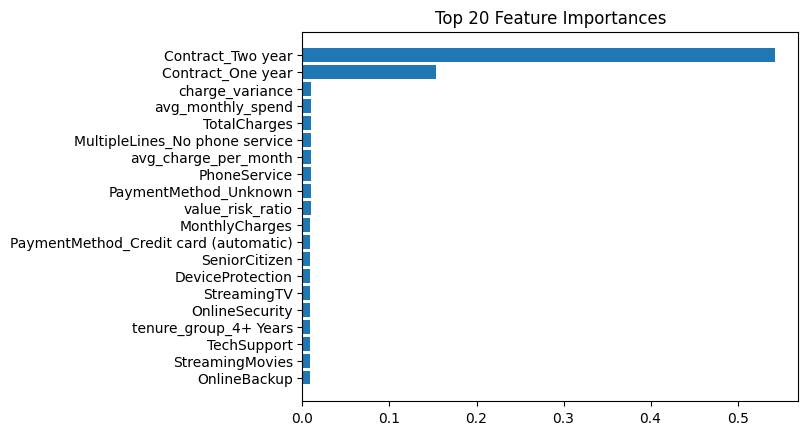

In [20]:
# Identify which features matter most
import matplotlib.pyplot as plt
import numpy as np

# For XGBoost
importance = model.feature_importances_
feature_names = X_train.columns
top_20 = np.argsort(importance)[-20:]

plt.barh(range(20), importance[top_20])
plt.yticks(range(20), feature_names[top_20])
plt.title('Top 20 Feature Importances')
plt.show()

# Action: Remove low-importance features to reduce noise

# CATBOOST 

In [ ]:
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report

df_original_original = pd.read_csv('../data/processed/cleaned_churn.csv')  # ← Different file!

In [ ]:
# Load ORIGINAL data (before feature engineering one-hot encoding)

# Keep categorical columns as TEXT
categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

# Verify they're text, not one-hot
print("Sample categorical values:")
for col in categorical_cols[:]:
    print(f"{col}: {df_original_original[col].unique()[:5]}")

# Now CatBoost will work!
feature_cols = [col for col in df_original_original.columns if col not in ['Churn', 'customerID']]
X = df_original_original[feature_cols]
y = df_original_original['Churn']

cat_features_indices = [i for i, col in enumerate(feature_cols) if col in categorical_cols]
print(f"\n✅ CatBoost will handle {len(cat_features_indices)} categorical columns natively")

# Train CatBoost
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_features_indices)

model = CatBoostClassifier(
    iterations=1000,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=3,
    cat_features=cat_features_indices,
    random_state=42,
    verbose=0
)

model.fit(train_pool, eval_set=test_pool, early_stopping_rounds=50, use_best_model=True)

y_proba = model.predict_proba(test_pool)[:, 1]
print(f"\n🎯 CatBoost AUC (Native Categorical): {roc_auc_score(y_test, y_proba):.3f}")

# feature eng 

In [ ]:
# Tenure group
bins = [0, 12, 24, 48, 60, float('inf')]
labels = ['0-12', '12-24', '24-48', '48-60', '60-72']
df_original_original['tenure_group'] = pd.cut(df_original_original['tenure'], bins=bins, labels=labels)

# Average monthly charge
df_original_original['avg_monthly_charge'] = df_original_original['TotalCharges'] / (df_original_original['tenure'] + 1)

# Number of services
services = [
    'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
    'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]
df_original_original['num_services'] = df_original_original[services].apply(lambda x: sum([1 if v in ['Yes','DSL','Fiber optic'] else 0 for v in x]), axis=1)

# Number of streaming services
df_original_original['num_streaming_services'] = df_original_original[['StreamingTV','StreamingMovies']].apply(lambda x: sum([1 if v=='Yes' else 0 for v in x]), axis=1)

# Tech support flag
df_original_original['has_tech_support'] = df_original_original['TechSupport'].apply(lambda x: 1 if x=='Yes' else 0)

# Paperless + Electronic check
df_original_original['paperless_echeck'] = ((df_original_original['PaperlessBilling']=='Yes') & (df_original_original['PaymentMethod']=='Electronic check')).astype(int)

# Long-term contract
df_original_original['is_long_contract'] = df_original_original['Contract'].apply(lambda x: 1 if x in ['One year','Two year'] else 0)

# Family status
df_original_original['family_status'] = df_original_original['Partner'] + '_' + df_original_original['Dependents']

# Tenure × Contract interaction
df_original_original['tenure_contract'] = df_original_original['tenure'].astype(str) + '_' + df_original_original['Contract']

## CATBOOST with feature eng

In [4]:
# ===========================
# 3. Define features
# ===========================

target_col = 'Churn'

# All features except customerID and target
feature_cols = [col for col in df_original_original.columns if col not in [target_col,'customerID']]

# Original categorical features + new categorical features
categorical_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
    'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
    'PaperlessBilling', 'PaymentMethod', 'tenure_group', 
    'family_status', 'tenure_contract'
]

# ===========================
# 4. Prepare X and y
# ===========================

X = df_original_original[feature_cols]
y = df_original_original[target_col].map({'No':0,'Yes':1})  # Convert to 0/1

# ===========================
# 5. Split data
# ===========================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===========================
# 6. CatBoost Pool
# ===========================

cat_features_indices = [i for i, col in enumerate(feature_cols) if col in categorical_cols]

train_pool = Pool(X_train, y_train, cat_features=cat_features_indices)
test_pool = Pool(X_test, y_test, cat_features=cat_features_indices)

# ===========================
# 7. Train CatBoost
# ===========================

model = CatBoostClassifier(
    iterations=1000,
    depth=6,
    learning_rate=0.05,
    loss_function='Logloss',
    cat_features=cat_features_indices,
    verbose=100,
    random_state=42,
    early_stopping_rounds=50,
    use_best_model=True
)

model.fit(train_pool, eval_set=test_pool)

# ===========================
# 8. Evaluate Model
# ===========================

y_pred = model.predict(test_pool)
y_proba = model.predict_proba(test_pool)[:,1]

print("="*60)
print("CATBOOST PERFORMANCE WITH FEATURE ENGINEERING")
print("="*60)
print(f"AUC-ROC: {roc_auc_score(y_test, y_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Retained','Churned']))

# ===========================
# 9. Feature Importance
# ===========================

feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': model.get_feature_importance()
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10))

0:	learn: 0.6716693	test: 0.6717244	best: 0.6717244 (0)	total: 221ms	remaining: 3m 40s
100:	learn: 0.5067219	test: 0.5074735	best: 0.5074578 (82)	total: 23s	remaining: 3m 24s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.5074488789
bestIteration = 107

Shrink model to first 108 iterations.
CATBOOST PERFORMANCE WITH FEATURE ENGINEERING
AUC-ROC: 0.789

Classification Report:
              precision    recall  f1-score   support

    Retained       0.88      0.66      0.75      6542
     Churned       0.70      0.90      0.78      5745

    accuracy                           0.77     12287
   macro avg       0.79      0.78      0.77     12287
weighted avg       0.79      0.77      0.77     12287


Top 10 Most Important Features:
             feature  importance
14          Contract   76.281800
25  is_long_contract   13.740908
12       StreamingTV    1.762756
6      MultipleLines    1.308903
9       OnlineBackup    1.221249
10  DeviceProtection    0.967694
8     Onlin